In [1]:
from pathlib import Path

retrieval_dir = Path("../src/radar_lwc/retrieval").resolve()
print(retrieval_dir)
print(list(retrieval_dir.glob("*.py")))


C:\Projects\Masterarbeit\dual_freq_radar_lwc\src\radar_lwc\retrieval
[WindowsPath('C:/Projects/Masterarbeit/dual_freq_radar_lwc/src/radar_lwc/retrieval/average_ze_time.py'), WindowsPath('C:/Projects/Masterarbeit/dual_freq_radar_lwc/src/radar_lwc/retrieval/ddwr_dh.py'), WindowsPath('C:/Projects/Masterarbeit/dual_freq_radar_lwc/src/radar_lwc/retrieval/dielectric.py'), WindowsPath('C:/Projects/Masterarbeit/dual_freq_radar_lwc/src/radar_lwc/retrieval/dq_retrieval.py'), WindowsPath('C:/Projects/Masterarbeit/dual_freq_radar_lwc/src/radar_lwc/retrieval/gas_attenuation.py'), WindowsPath('C:/Projects/Masterarbeit/dual_freq_radar_lwc/src/radar_lwc/retrieval/kappa_liquid.py'), WindowsPath('C:/Projects/Masterarbeit/dual_freq_radar_lwc/src/radar_lwc/retrieval/zhu.py')]


In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

sys.path.append(str(Path("../src").resolve()))

# Preprocessing
from radar_lwc.preprocessing.align import align_to_reference_time
from radar_lwc.preprocessing.chirps import combine_chirps
from radar_lwc.preprocessing.clean import drop_duplicate_times
from radar_lwc.preprocessing.get_reflectivity import get_reflectivity

# Retrieval
from radar_lwc.retrieval.average_ze_time import avg_ze_time
from radar_lwc.retrieval.dielectric import epsilon_water_liebe1989
from radar_lwc.retrieval.kappa_liquid import kappa_liquid
from radar_lwc.retrieval.zhu import retrieve_lwc_zhu
# NEW: integral DQ retrieval. Copy dq_retrieval.py into src/radar_lwc/retrieval/
from radar_lwc.retrieval.dq_retrieval import retrieve_lwc_dq


In [4]:
# NOTE: load the file with the REAL computed alpha/kappa, not the placeholder
# constants. (retrieval_input_2km.nc holds the 0.65/0.14/4.29/0.80 placeholders.)
in_path = Path("../data/processed/retrieval_input_2km_alpha_kappa_calculated.nc")
ds_retrieval = xr.open_dataset(in_path)
in_path_2 = Path("../data/processed/retrieval_input_2km.nc")
ds_retrieval_2 = xr.open_dataset(in_path_2)
print(ds_retrieval)

# common_mask (cloud AND drizzle-free) must be present in the file. If you only
# saved cloud_mask, rebuild common_mask here or in notebook 03 before this step.
assert "common_mask" in ds_retrieval, "common_mask missing - build it in notebook 03"


<xarray.Dataset> Size: 40MB
Dimensions:        (Time: 10441, range: 74)
Coordinates:
  * Time           (Time) datetime64[ns] 84kB 2023-09-28T07:00:04 ... 2023-09...
  * range          (range) float32 296B 111.8 134.2 ... 1.971e+03 1.998e+03
    TAlt           (range) float32 296B ...
    HAlt           (range) float32 296B ...
Data variables: (12/14)
    Ze_W           (Time, range) float32 3MB ...
    Ze_Ka          (Time, range) float32 3MB ...
    T_cloud        (Time, range) float32 3MB ...
    LWP            (Time) float32 42kB ...
    DWR            (Time, range) float32 3MB ...
    cloud_mask     (Time, range) bool 773kB ...
    ...             ...
    alpha_W        (Time, range) float64 6MB ...
    alpha_Ka       (Time, range) float64 6MB ...
    kappa_W        (Time, range) float32 3MB ...
    kappa_Ka       (Time, range) float32 3MB ...
    MeanVel_W      (Time, range) float32 3MB ...
    MeanVel_Ka     (Time, range) float32 3MB ...
Attributes:
    description:  Prepared in

 ================================================================================================================================================================================================

 DIAGNOSE THE DRIZZLE-FILTER KILL RATE (why is it 63%, not Zhu's 5.3%?)

 ================================================================================================================================================================================================

 Zhu's 5.3% came from a single beam/pulse/time-matched W/Ka radar. If Cabauw

 uses two independent radars, the velocity DIFFERENCE carries sampling-mismatch

 and doubled Doppler noise, not drizzle. Real drizzle clusters near cloud BASE;

 noise/mismatch is spread through the whole cloud. This cell tells them apart.

velocity-difference stats (in cloud):
  mean   = -0.006 m/s   (near 0 = well matched)
  median = -0.002 m/s
  std    = 0.141 m/s     (>0.1 alone explains high kill rate)
  fraction |dv| > 0.1 m/s: 12.7%


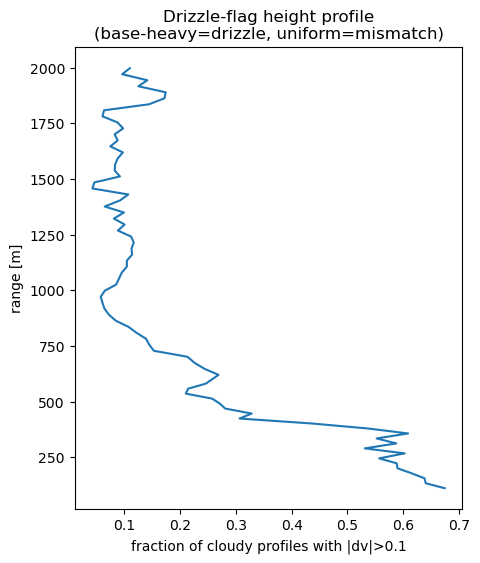

In [5]:
if {"MeanVel_W", "MeanVel_Ka"}.issubset(ds_retrieval_2.variables):
    dv = (ds_retrieval_2["MeanVel_W"] - ds_retrieval_2["MeanVel_Ka"]).where(ds_retrieval_2["common_mask"])
    dv_vals = dv.values[np.isfinite(dv.values)]
    print(f"velocity-difference stats (in cloud):")
    print(f"  mean   = {dv_vals.mean():+.3f} m/s   (near 0 = well matched)")
    print(f"  median = {np.median(dv_vals):+.3f} m/s")
    print(f"  std    = {dv_vals.std():.3f} m/s     (>0.1 alone explains high kill rate)")
    print(f"  fraction |dv| > 0.1 m/s: {(np.abs(dv_vals) > 0.1).mean():.1%}")

    # Is exceedance near cloud base (real drizzle) or everywhere (mismatch)?
    exceed = (np.abs(dv) > 0.1) & ds_retrieval_2["common_mask"]
    frac_by_height = exceed.sum("Time") / ds_retrieval_2["common_mask"].sum("Time")
    fig, ax = plt.subplots(figsize=(5, 6))
    frac_by_height.plot(y="range", ax=ax)
    ax.set_xlabel("fraction of cloudy profiles with |dv|>0.1")
    ax.set_ylabel("range [m]")
    ax.set_title("Drizzle-flag height profile\n(base-heavy=drizzle, uniform=mismatch)")
    plt.show()
else:
    print("MeanVel_W / MeanVel_Ka not in dataset - add them in notebook 02 to run this.")


 ================================================================================================================================================================================================

 INTEGRAL DQ RETRIEVAL - RAW (no time averaging), Tmean kappa

 ================================================================================================================================================================================================

In [ ]:
lwc, dq = retrieve_lwc_dq(
    dwr=ds_retrieval["DWR"],
    kappa_w=ds_retrieval["kappa_W"],
    kappa_ka=ds_retrieval["kappa_Ka"],
    alpha_w=ds_retrieval["alpha_W"],
    alpha_ka=ds_retrieval["alpha_Ka"],
    common_mask=ds_retrieval["common_mask"],
    min_cloud_gates=4,
    fit_degree=2,
    kappa_mode="tmean",
)


 DQ (cumulative liquid water) - the curve we smooth BEFORE differentiating

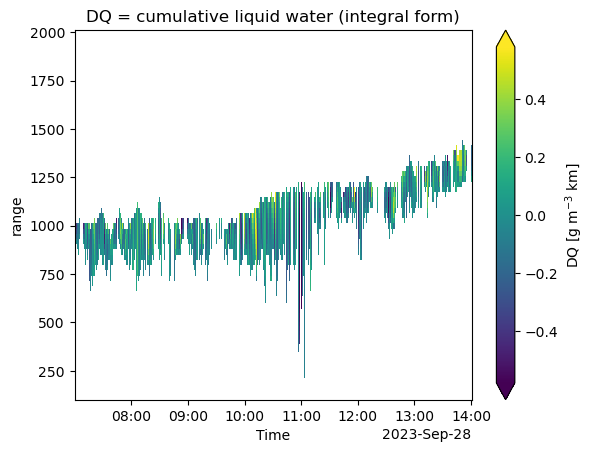

In [ ]:
dq.plot(
    x="Time", y="range", cmap="viridis", robust=True,
    cbar_kwargs={"label": "DQ [g m$^{-3}$ km]"},
)
plt.title("DQ = cumulative liquid water (integral form)")
plt.show()


 LWC - Without Averaging

<xarray.DataArray 'LWC' (Time: 10441, range: 74)> Size: 6MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(10441, 74))
Coordinates:
  * Time     (Time) datetime64[ns] 84kB 2023-09-28T07:00:04 ... 2023-09-28T14...
  * range    (range) float32 296B 111.8 134.2 156.5 ... 1.971e+03 1.998e+03
    TAlt     (range) float32 296B ...
    HAlt     (range) float32 296B ...
Attributes:
    units:      g m-3
    long_name:  Liquid Water Content (integral DQ retrieval)
    method:     DQ polynomial fit deg=2, kappa_mode=tmean


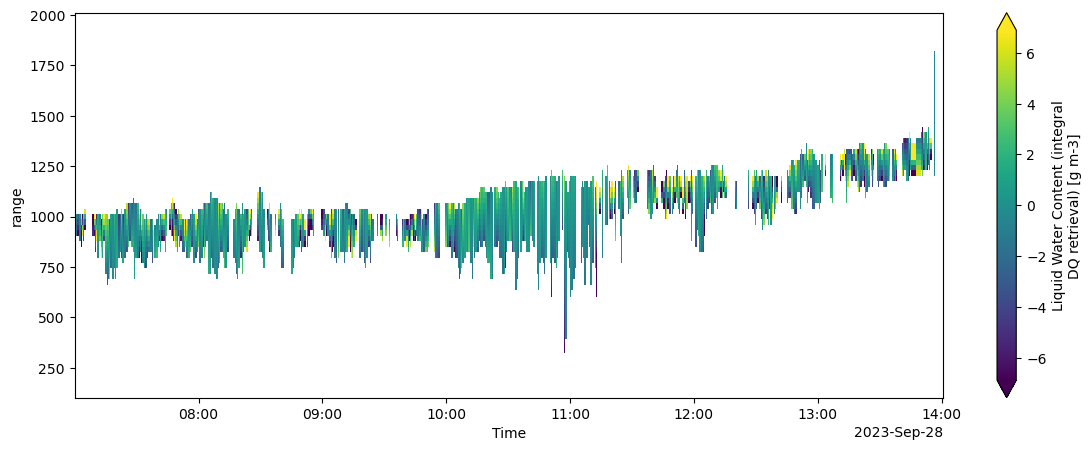

In [ ]:
print(lwc)
lwc.plot(x="Time", y="range", figsize=(14, 5), cmap="viridis", robust=True)
plt.show()

In [ ]:
print(f"Fraction LWC < 0: "
      f"{float((lwc < 0).sum() / lwc.notnull().sum()):.2%}")
print(f"LWC quantiles: "
      f"p05={float(lwc.quantile(0.05)):.2f}, "
      f"p50={float(lwc.quantile(0.5)):.2f}, "
      f"p95={float(lwc.quantile(0.95)):.2f} g/m³")


Fraction LWC < 0: 45.81%
LWC quantiles: p05=-4.42, p50=0.15, p95=4.49 g/m³


In [ ]:
# %%

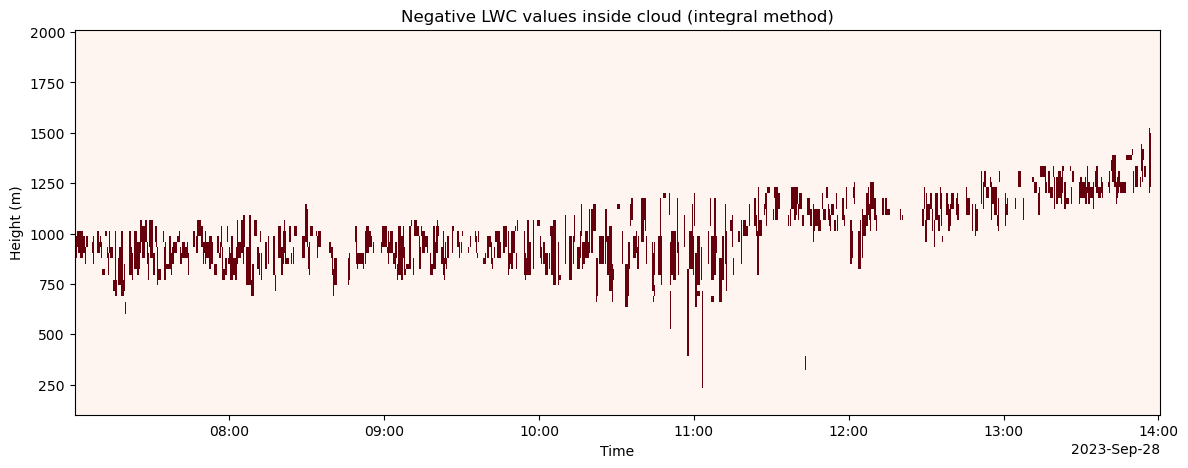

In [ ]:
negative_lwc = (lwc < 0) & ds_retrieval["common_mask"]
plt.figure(figsize=(14, 5))
negative_lwc.astype(int).plot(x="Time", y="range", cmap="Reds", add_colorbar=False)
plt.title("Negative LWC values inside cloud (integral method)")
plt.xlabel("Time"); plt.ylabel("Height (m)")
plt.show()


In [ ]:
# %%

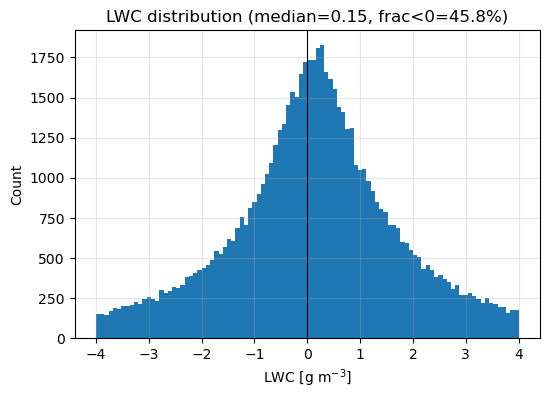

In [ ]:
vals = lwc.where(ds_retrieval["common_mask"]).values
vals = vals[np.isfinite(vals)]
plt.figure(figsize=(6, 4))
plt.hist(vals, bins=100, range=(-4, 4))
plt.axvline(0, color="k", lw=0.8)
plt.xlabel("LWC [g m$^{-3}$]"); plt.ylabel("Count")
plt.title(f"LWC distribution (median={np.median(vals):.2f}, "
          f"frac<0={(vals < 0).mean():.1%})")
plt.grid(alpha=0.3)
plt.show()


 ================================================================================================================================================================================================

 TIME-AVERAGED DWR (30 s) THEN DQ RETRIEVAL

 The integral method still benefits from beating down per-gate DWR noise first.

 Average in LINEAR Ze, then form DWR, exactly as in notebook 04.

 ================================================================================================================================================================================================

In [ ]:
ze_ka_avg = avg_ze_time(ds_retrieval["Ze_Ka"].sel(range=slice(0, 2000)), window_s=30)
ze_w_avg  = avg_ze_time(ds_retrieval["Ze_W"].sel(range=slice(0, 2000)),  window_s=30)

dwr_2km_smoothed = ze_ka_avg - ze_w_avg
dwr_2km_smoothed.name = "DWR"


In [ ]:
# %%

In [ ]:
gate_threshold = 1.0  # dB

def despike_1d(dwr_1d, threshold=1.0):
    out = dwr_1d.copy()
    n = len(dwr_1d)
    for i in range(1, n - 1):
        left = dwr_1d[i] - dwr_1d[i - 1]
        right = dwr_1d[i] - dwr_1d[i + 1]
        is_spike = (
            np.abs(left) > threshold
            and np.abs(right) > threshold
            and np.sign(left) == np.sign(right)
        )
        if is_spike and not (np.isnan(dwr_1d[i - 1]) or np.isnan(dwr_1d[i + 1]) or np.isnan(dwr_1d[i])):
            out[i] = dwr_1d[i - 1] + (dwr_1d[i + 1] - dwr_1d[i - 1]) * 0.5
    return out

dwr_2km_filt = xr.apply_ufunc(
    despike_1d, dwr_2km_smoothed,
    input_core_dims=[["range"]], output_core_dims=[["range"]],
    kwargs={"threshold": gate_threshold}, vectorize=True,
)
dwr_2km_filt.name = "DWR"
dwr_2km_filt.attrs = dwr_2km_smoothed.attrs

n_replaced = int((np.abs(dwr_2km_filt - dwr_2km_smoothed) > 1e-9).sum())
print(f"Gates replaced by interpolation: {n_replaced} "
      f"({n_replaced / dwr_2km_smoothed.size:.2%} of all gates)")


Gates replaced by interpolation: 58605 (7.59% of all gates)


In [ ]:
lwc_2, dq_2 = retrieve_lwc_dq(
    dwr=dwr_2km_filt,                       # despiked, 30 s averaged DWR
    kappa_w=ds_retrieval["kappa_W"],
    kappa_ka=ds_retrieval["kappa_Ka"],
    alpha_w=ds_retrieval["alpha_W"],
    alpha_ka=ds_retrieval["alpha_Ka"],
    common_mask=ds_retrieval["common_mask"],
    min_cloud_gates=4,
    fit_degree=3,
    kappa_mode="tmean",
)


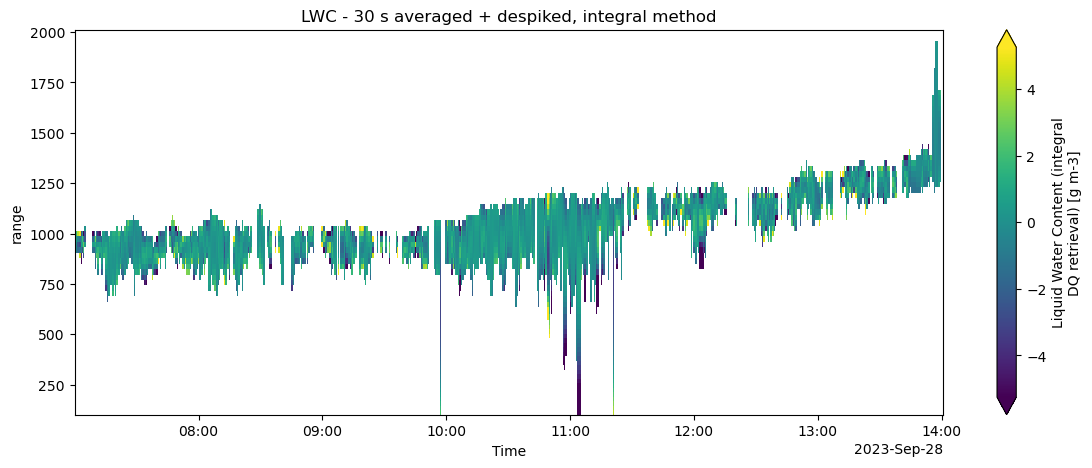

In [ ]:
lwc_2.plot(x="Time", y="range", figsize=(14, 5), cmap="viridis", robust=True)
plt.title("LWC - 30 s averaged + despiked, integral method")
plt.show()


In [ ]:
print(f"Fraction LWC < 0: "
      f"{float((lwc_2 < 0).sum() / lwc_2.notnull().sum()):.2%}")
print(f"LWC quantiles: "
      f"p05={float(lwc_2.quantile(0.05)):.2f}, "
      f"p50={float(lwc_2.quantile(0.5)):.2f}, "
      f"p95={float(lwc_2.quantile(0.95)):.2f} g/m³")


Fraction LWC < 0: 41.79%
LWC quantiles: p05=-2.99, p50=0.16, p95=2.01 g/m³


 ================================================================================================================================================================================================

 KAPPA-RESOLVED VARIANT (answers Q1: keep kappa inside the integral)

 For thin, narrow-temperature clouds this should be ~identical to Tmean.

 ================================================================================================================================================================================================

In [ ]:
lwc_res, dq_res = retrieve_lwc_dq(
    dwr=dwr_2km_filt,
    kappa_w=ds_retrieval["kappa_W"],
    kappa_ka=ds_retrieval["kappa_Ka"],
    alpha_w=ds_retrieval["alpha_W"],
    alpha_ka=ds_retrieval["alpha_Ka"],
    common_mask=ds_retrieval["common_mask"],
    min_cloud_gates=4,
    fit_degree=3,
    kappa_mode="resolved",
)

diff = (lwc_res - lwc_2).where(ds_retrieval["common_mask"])
print(f"Tmean vs resolved: mean |diff| = {float(np.abs(diff).mean()):.4f} g/m³ "
      f"(expected tiny for ~1 K clouds)")


Tmean vs resolved: mean |diff| = 0.0073 g/m³ (expected tiny for ~1 K clouds)


 ================================================================================================================================================================================================

 LWP CLOSURE: DQ-derived radar LWP  vs  MWR LWP

 ================================================================================================================================================================================================

 LWP_radar = DQ(cloud top) * 1000  [g m-2]. Take the top valid DQ per profile.

In [ ]:
def dq_to_lwp(dq_da, mask):
    """LWP [g m-2] = DQ at the highest in-cloud gate, per profile."""
    dq_masked = dq_da.where(mask)
    # highest finite gate along range
    lwp = dq_masked.ffill("range").isel(range=-1) * 1000.0
    lwp = lwp.where(mask.any("range"))
    lwp.attrs["units"] = "g m-2"
    return lwp

lwp_radar = dq_to_lwp(dq_2, ds_retrieval["common_mask"])

# Optional: time-average LWP over 5 min to beat down residual noise
lwp_radar_5min = lwp_radar.rolling(Time=int(5 * 60 / 30), center=True, min_periods=1).mean()


Per-profile closure:


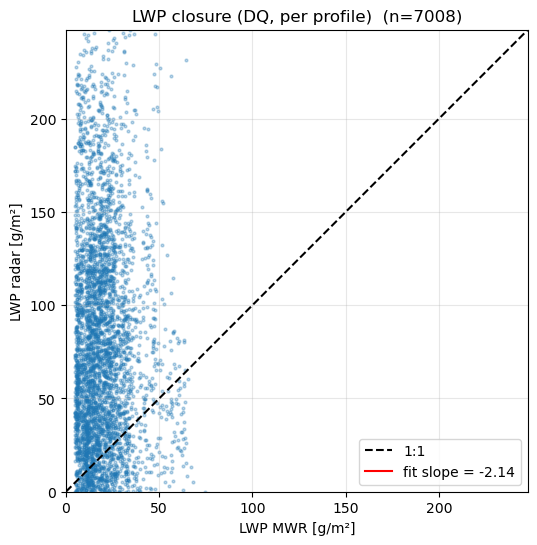

  slope through origin: -2.14   (want ~1.0)
  correlation:          -0.18   (want > 0.7)
  bias radar - MWR:     -52.5 g/m²

5-min averaged closure (noise averages down here):


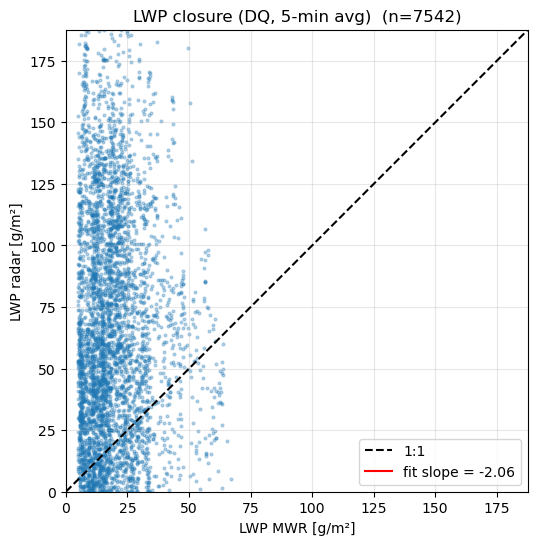

  slope through origin: -2.06   (want ~1.0)
  correlation:          -0.18   (want > 0.7)
  bias radar - MWR:     -52.6 g/m²


In [ ]:
def closure_plot(x, y, title):
    good = np.isfinite(x) & np.isfinite(y) & (x > 5)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(x[good], y[good], s=4, alpha=0.3)
    lim = max(np.nanpercentile(x[good], 99), np.nanpercentile(y[good], 99))
    ax.plot([0, lim], [0, lim], "k--", label="1:1")
    slope = np.nansum(x[good] * y[good]) / np.nansum(x[good] ** 2)
    ax.plot([0, lim], [0, slope * lim], "r-", label=f"fit slope = {slope:.2f}")
    ax.set_xlabel("LWP MWR [g/m²]"); ax.set_ylabel("LWP radar [g/m²]")
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend()
    ax.set_title(f"{title}  (n={good.sum()})")
    plt.show()
    corr = np.corrcoef(x[good], y[good])[0, 1]
    print(f"  slope through origin: {slope:.2f}   (want ~1.0)")
    print(f"  correlation:          {corr:.2f}   (want > 0.7)")
    print(f"  bias radar - MWR:     {np.nanmean(y[good] - x[good]):+.1f} g/m²")

print("Per-profile closure:")
closure_plot(ds_retrieval["LWP"].values, lwp_radar.values, "LWP closure (DQ, per profile)")

print("\n5-min averaged closure (noise averages down here):")
closure_plot(ds_retrieval["LWP"].values, lwp_radar_5min.values, "LWP closure (DQ, 5-min avg)")


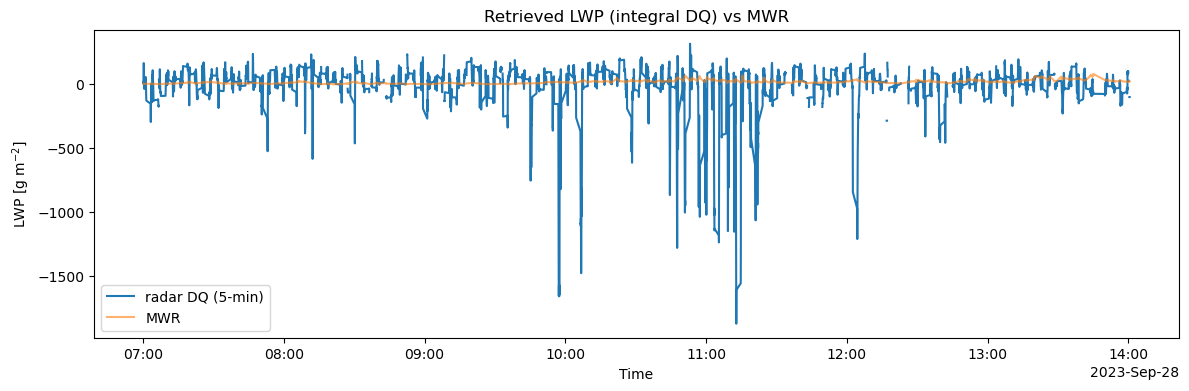

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
lwp_radar_5min.plot(ax=ax, label="radar DQ (5-min)")
ds_retrieval["LWP"].plot(ax=ax, label="MWR", alpha=0.6)
ax.set_title("Retrieved LWP (integral DQ) vs MWR")
ax.set_ylabel("LWP [g m$^{-2}$]"); ax.set_xlabel("Time"); ax.legend()
plt.show()


 ================================================================================================================================================================================================

 SIDE-BY-SIDE: integral DQ  vs  Zhu local-derivative (same input DWR)

 ================================================================================================================================================================================================

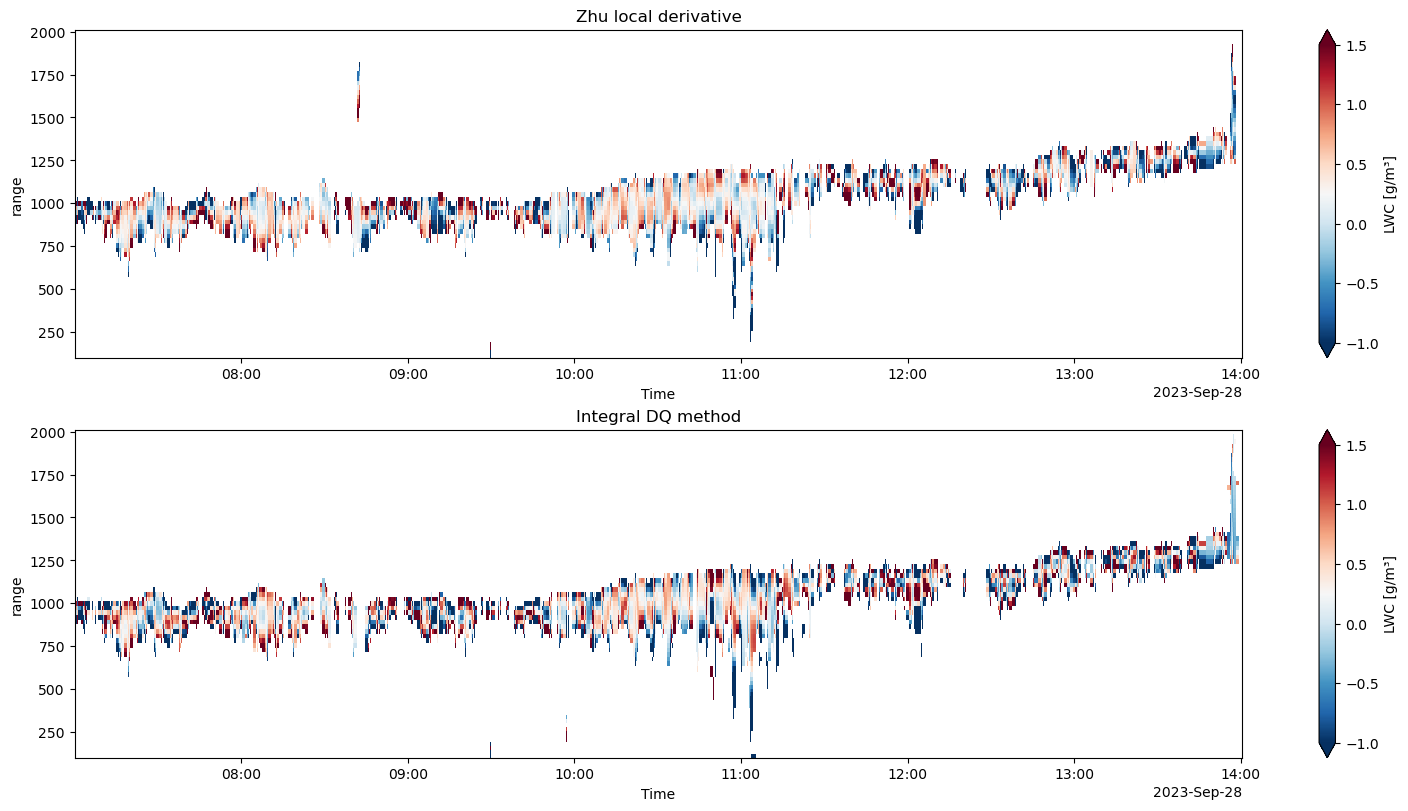

Zhu   fraction LWC<0: 36.0%
DQ    fraction LWC<0: 41.8%


In [ ]:
lwc_zhu, deriv_zhu = retrieve_lwc_zhu(
    dwr=dwr_2km_filt,
    kappa_w=ds_retrieval["kappa_W"],
    kappa_ka=ds_retrieval["kappa_Ka"],
    alpha_w=ds_retrieval["alpha_W"],
    alpha_ka=ds_retrieval["alpha_Ka"],
    cloud_mask=ds_retrieval["common_mask"],
    N_default=9,
    min_cloud_gates=3,
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), constrained_layout=True)
lwc_zhu.where(ds_retrieval["common_mask"]).plot(
    x="Time", y="range", ax=axes[0], vmin=-1, vmax=1.5, cmap="RdBu_r",
    cbar_kwargs={"label": "LWC [g/m³]"})
axes[0].set_title("Zhu local derivative")
lwc_2.where(ds_retrieval["common_mask"]).plot(
    x="Time", y="range", ax=axes[1], vmin=-1, vmax=1.5, cmap="RdBu_r",
    cbar_kwargs={"label": "LWC [g/m³]"})
axes[1].set_title("Integral DQ method")
plt.show()

print(f"Zhu   fraction LWC<0: {float((lwc_zhu < 0).sum()/lwc_zhu.notnull().sum()):.1%}")
print(f"DQ    fraction LWC<0: {float((lwc_2   < 0).sum()/lwc_2.notnull().sum()):.1%}")
